In [ ]:
!pip install geopandas folium duckdb matplotlib -q
print("✅ Pronto!")

✅ Pronto!


In [ ]:
import geopandas as gpd
import folium
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [ ]:
conn = duckdb.connect("dados/transporte_sp.duckdb")

df_metro     = conn.execute("SELECT * FROM metro").df()
df_corredores = conn.execute("SELECT * FROM corredores").df()
df_terminais  = conn.execute("SELECT * FROM terminais").df()

conn.close()

print(f"✅ Estações de metrô:    {len(df_metro)}")
print(f"✅ Corredores de ônibus: {len(df_corredores)}")
print(f"✅ Terminais de ônibus:  {len(df_terminais)}")

✅ Estações de metrô:    203
✅ Corredores de ônibus: 51
✅ Terminais de ônibus:  145


In [ ]:
print("=== METRÔ ===")
print(df_metro.columns.tolist())
df_metro.head(3)

print("=== CORREDORES ===")
print(df_corredores.columns.tolist())
df_corredores.head(3)

print("=== TERMINAIS ===")
print(df_terminais.columns.tolist())
df_terminais.head(3)

=== METRÔ ===
['ID', 'DATA', 'LIN_NUM', 'LIN_COR', 'NOM_EST', 'N_EST_AC', 'ANO', 'MUNIC', 'NOM_DIS', 'STATUS', 'GESTAO', 'OBS', 'geometry']
=== CORREDORES ===
['ID', 'LENGTH', 'DIR', 'DATA', 'STATUS', 'GESTAO', 'NOM_CORR', 'N_CORR_AC', 'EXT_KM', 'ANO', 'OBS', 'geometry']
=== TERMINAIS ===
['ID', 'DATA', 'NOM_TER', 'N_TER_AC', 'ANO', 'MUNIC', 'NOM_DIS', 'STATUS', 'GESTAO', 'CATEG', 'LINHAS', 'OBS', 'geometry']


,ID,DATA,NOM_TER,N_TER_AC,ANO,MUNIC,NOM_DIS,STATUS,GESTAO,CATEG,LINHAS,OBS,geometry
0,4281,4289,CAUCAIA DO ALTO,Caucaia do Alto,NaN,COTIA,CAUCAIA DO ALTO,OPERACAO,EMTU,LOCAL,NaN,<NA>,POINT (-47.020432 -23.687234)
1,4289,5352,JORGE NELSON NEVES,Jorge Nelson Neves,2022.0,VARGEM GRANDE PAULISTA,VARGEM GRANDE PAULISTA,OPERACAO,PREFEITURA,LOCAL,7.0,<NA>,POINT (-47.023953 -23.606107)
2,4297,4297,EMBU GUACU,Embu-Guaçu,NaN,EMBU GUACU,EMBU GUACU,OPERACAO,EMTU,LOCAL,NaN,<NA>,POINT (-46.817828 -23.832344)


In [ ]:
metro      = gpd.read_file("dados/MEOP25_RMSP_CEM.shp")
corredores = gpd.read_file("dados/ONCO25_RMSP_CEM.shp")
terminais  = gpd.read_file("dados/ONTE25_RMSP_CEM.shp")

print(f"CRS metrô: {metro.crs}")
print(f"CRS corredores: {corredores.crs}")
print(f"CRS terminais: {terminais.crs}")

CRS metrô: EPSG:4674
CRS corredores: EPSG:4674
CRS terminais: EPSG:4674


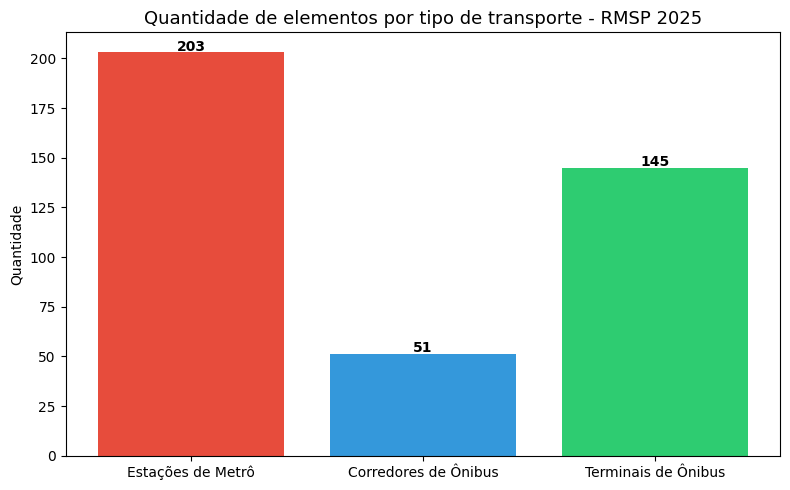

In [ ]:
categorias  = ["Estações de Metrô", "Corredores de Ônibus", "Terminais de Ônibus"]
quantidades = [len(metro), len(corredores), len(terminais)]
cores       = ["#e74c3c", "#3498db", "#2ecc71"]

plt.figure(figsize=(8, 5))
bars = plt.bar(categorias, quantidades, color=cores)
plt.title("Quantidade de elementos por tipo de transporte - RMSP 2025", fontsize=13)
plt.ylabel("Quantidade")
for bar, val in zip(bars, quantidades):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

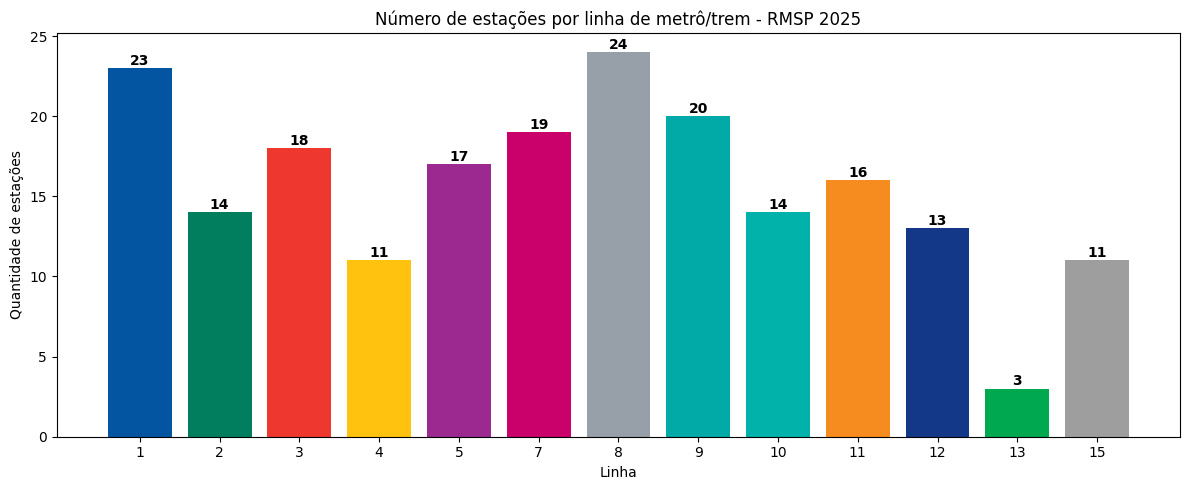

In [ ]:
# Agrupa por número e cor da linha
por_linha = metro.groupby(["LIN_NUM", "LIN_COR"])["NOM_EST"].count().reset_index()
por_linha.columns = ["Número", "Cor", "Estações"]
por_linha = por_linha.sort_values("Número")

# Mapa de cores reais das linhas
cores_linhas = {
    "AZUL":      "#0455A1",
    "VERDE":     "#007E5E",
    "VERMELHA":  "#EE372F",
    "AMARELA":   "#FFC20E",
    "LILAS":     "#9B2990",
    "RUBI":      "#CA016B",
    "DIAMANTE":  "#97A0A8",
    "ESMERALDA": "#01A9A7",
    "SAFIRA":    "#133887",
    "TURQUESA":  "#00B2A9",
    "CORAL":     "#F68B1F",
    "JADE":      "#00A84F",
    "PRATA":     "#9E9E9E",
}

cores = [cores_linhas.get(c.upper(), "#888888") for c in por_linha["Cor"]]

plt.figure(figsize=(12, 5))
bars = plt.bar(por_linha["Número"].astype(str), por_linha["Estações"], color=cores)
plt.title("Número de estações por linha de metrô/trem - RMSP 2025")
plt.xlabel("Linha")
plt.ylabel("Quantidade de estações")
for bar, val in zip(bars, por_linha["Estações"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
mapa = folium.Map(location=[-23.55, -46.63], zoom_start=11)

# Corredores de ônibus em azul
folium.GeoJson(
    corredores,
    name="Corredores de Ônibus",
    style_function=lambda x: {
        "color": "#3498db", "weight": 3, "opacity": 0.7
    }
).add_to(mapa)

# Terminais de ônibus em verde
for _, row in terminais.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color="#2ecc71",
        fill=True,
        fill_opacity=0.8,
        popup=row.get("NM_TERM", "Terminal")
    ).add_to(mapa)

# Estações de metrô em vermelho
for _, row in metro.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        color="#e74c3c",
        fill=True,
        fill_opacity=0.9,
        popup=row.get("NM_ESTACAO", "Estação")
    ).add_to(mapa)

folium.LayerControl().add_to(mapa)
mapa

In [ ]:
if "EXTENSAO" in corredores.columns or "EXT_KM" in corredores.columns:
    col_ext = "EXTENSAO" if "EXTENSAO" in corredores.columns else "EXT_KM"
    print(f"Extensão total dos corredores: {corredores[col_ext].sum():.1f} km")
    print(f"Corredor mais longo: {corredores[col_ext].max():.1f} km")
    print(f"Corredor mais curto: {corredores[col_ext].min():.1f} km")
else:
    print("Colunas disponíveis em corredores:")
    print(corredores.columns.tolist())

Extensão total dos corredores: 206.7 km
Corredor mais longo: 17.3 km
Corredor mais curto: 0.2 km


## 📋 Proposta de Análise

Com base nos dados coletados sobre o transporte público da Região
Metropolitana de São Paulo, propomos analisar a **equidade de cobertura
por município**:

- Cruzar as estações de metrô e terminais de ônibus com os limites
  municipais da RMSP
- Calcular a densidade de equipamentos de transporte por km² em cada município
- Identificar municípios com menor acesso ao transporte de alta capacidade
- Comparar a cobertura com dados populacionais do IBGE Censo 2022

**Hipótese:** Municípios periféricos da região metropolitana possuem
significativamente menos acesso ao transporte público de alta capacidade
(metrô e corredores de ônibus) do que os municípios centrais, evidenciando
desigualdade na distribuição da infraestrutura de mobilidade urbana na RMSP.